In [58]:
include("../src/GeoUtils.jl");
import .GeoUtils as GU
using CSV
using DataFrames
using GMT


In [42]:
lon1=73+58/60
lat1=40+45/60
lon2=0+10/60
lat2=51+32/60
Npoints_GMT=500
print([lon1 lat1 lon2 lat2])

[73.96666666666667 40.75 0.16666666666666666 51.53333333333333]

In [59]:
total_distance=GU.rhumb_distance(lon1,lat1,lon2,lat2)
true_distance=GU.geodesic_distance(lon1,lat1,lon2,lat2)
spherical_distance=GU.haversine(lon1, lat1, lon2, lat2)
azimuth_=GU.Eval_azimuth(lon1,lat1,lon2,lat2)
azimuth_g=GU.geodesic_azimuth(lon1, lat1, lon2, lat2)

println("total_distance: $total_distance ; true distance: $true_distance ; spherical distance: $spherical_distance")

print(GU.destination(lon1,lat1,azimuth_,total_distance))
my_geod_destination=GU.geodesic_destination(lon1,lat1,azimuth_,total_distance)

total_distance: 5784.841117456063 ; true distance: 5576.587488332837 ; spherical distance: 5561.596288389489
(0.16666666666662877, 51.53333333333333)

(9.096000351331782, 31.720883850512507)

In [60]:
(true_distance-spherical_distance)*100/true_distance

0.2688238994674088

In [55]:
(true_distance-total_distance)*100/true_distance

-3.734427722310967

In [44]:
azimuth_

-78.03728534307717

In [45]:
azimuth_g


-51.25335633230464

In [38]:
result=GU.destination(lon1,lat1,azimuth_g,total_distance)

(-7.3849226279332925, 73.3108251810045)

In [39]:
path_geodesic=GU.geodesic_generate_path(lon1,lat1,lon2,lat2,10)
path_rhumb=GU.generate_path(lon1,lat1,lon2,lat2,10)
path_rhumb2=GU.generate_path(lon1,lat1,result[1],result[2],10)
path_geodesic2=GU.geodesic_generate_path(lon1,lat1,my_geod_destination[1],my_geod_destination[2],10)

579×2 Matrix{Float64}:
   73.9667   40.75
   73.8507   40.7685
   73.7346   40.7868
   73.6185   40.8051
   73.5023   40.8232
   73.386    40.8412
   73.2697   40.8591
   73.1534   40.8769
   73.0369   40.8946
   72.9204   40.9121
    ⋮        
    9.83611  32.0718
    9.74329  32.0282
    9.65056  31.9845
    9.55792  31.9407
    9.46536  31.8969
    9.37289  31.853
    9.28051  31.809
    9.18821  31.765
 -350.904    31.7209

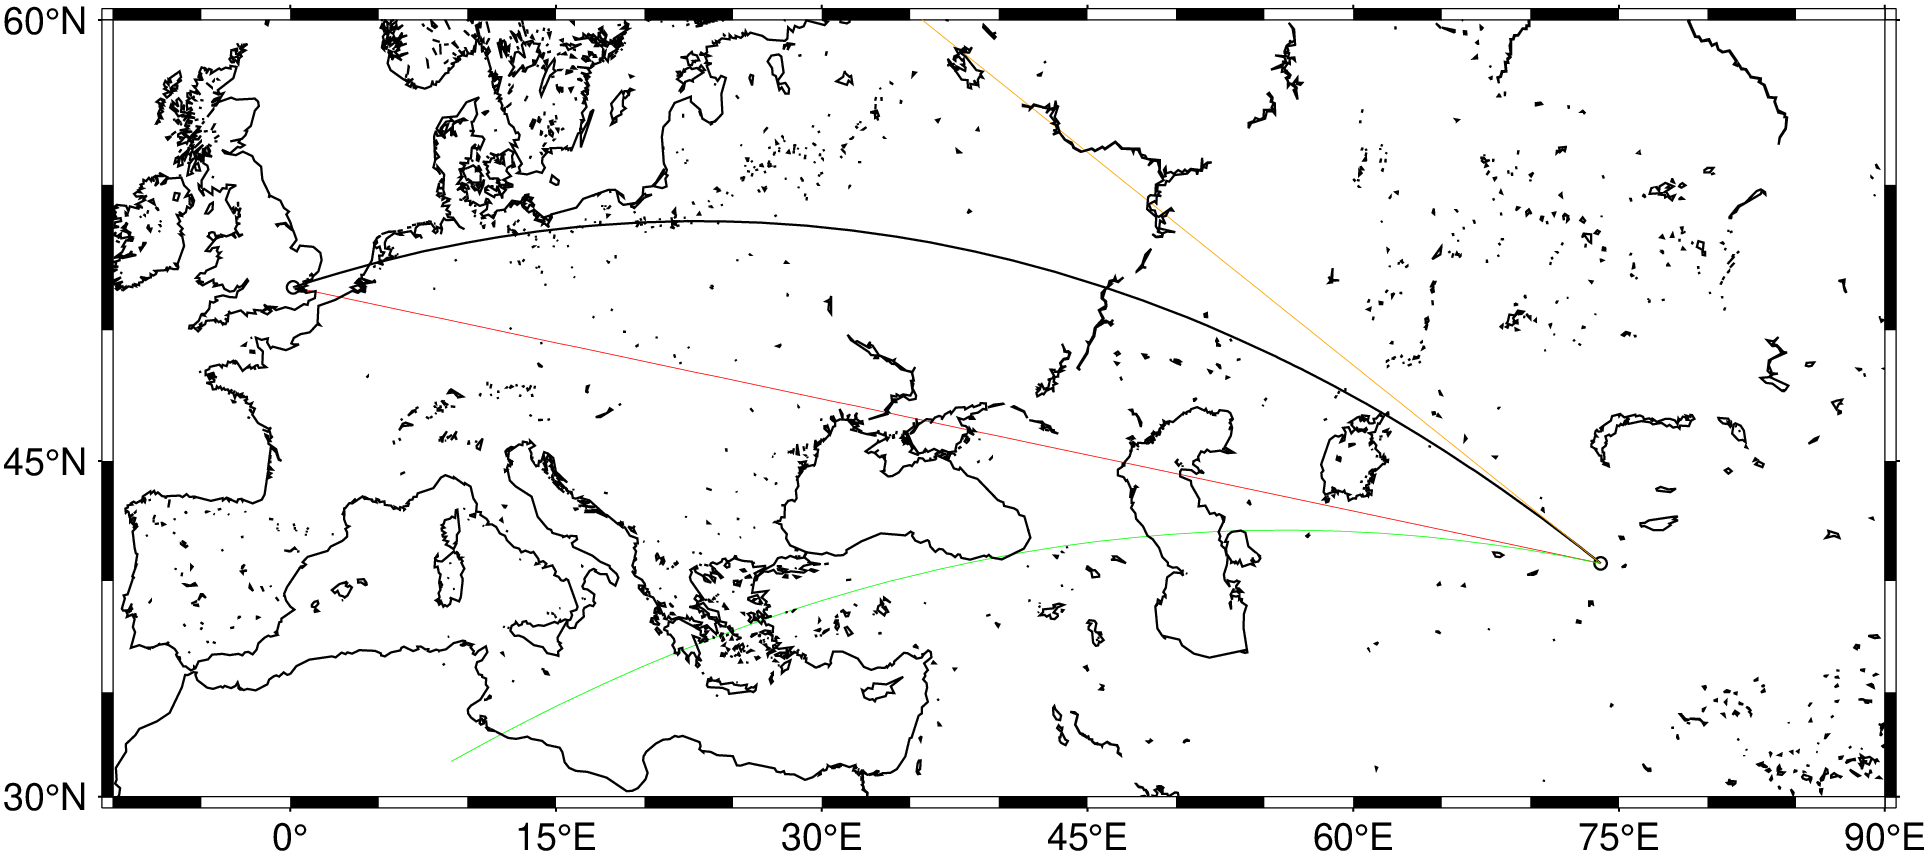

In [40]:
GMT.plot(region=[-10,90,30,60],x=path_geodesic[:,1],y=path_geodesic[:,2],J="M15c")
GMT.scatter!(x=[lon1,lon2],y=[lat1,lat2],S="c3p")
GMT.plot!(x=path_rhumb[:,1],y=path_rhumb[:,2],pen="0.1p,red")
GMT.plot!(x=path_rhumb2[:,1],y=path_rhumb2[:,2],pen="0.1p,orange")
GMT.plot!(x=path_geodesic2[:,1],y=path_geodesic2[:,2],pen="0.1p,green")
GMT.coast!(show=true)